In [1]:
from mca_shared_izzy.mca_shared_izzyv1 import ws_curl
#from mca_shared_izzy.mca_shared_si_conc import dot_xa_masked
%load_ext autoreload
%autoreload 2

ModuleNotFoundError: No module named 'mca_shared_izzy.mca_shared_izzyv1'

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import xeofs as xe
from pygments.modeline import modeline_re

from geometry_izzyv1 import grad_sphere
from regression_izzyv1 import linregress_3D
import cartopy.crs as ccrs
crs = ccrs.PlateCarree()
import warnings
import os
import requests
from bs4 import BeautifulSoup
#import copernicusmarine as cm
warnings.filterwarnings('ignore')

In [3]:
# constant
rho_a = 1.225 # air density kg m-3
Cd = 1.5e-3 # drag coeff

In [4]:
gridtype = 'remapcon'

In [5]:
import netCDF4
import h5netcdf

In [6]:
# #downloading SI_drift data noaa
# archive_url = "https://noaadata.apps.nsidc.org/NOAA/G02202_V5/south/monthly/"
#
# r = requests.get(archive_url)
#
# data = BeautifulSoup(r.text, "html.parser")
#
# for l in data.find_all("a")[1:]:
# 	r = requests.get(archive_url + l["href"])
# 	with open(l["href"], "wb") as f:
#     	         f.write(r.content)

In [7]:
# #downloading SI_conc data noaa
# archive_url_conc = "https://noaadata.apps.nsidc.org/NOAA/G02202_V4/south/monthly/"
#
# r_conc = requests.get(archive_url_conc)
#
# data_conc = BeautifulSoup(r_conc.text, "html.parser")
#
# for l in data_conc.find_all("a")[1:]:
# 	r_conc = requests.get(archive_url_conc + l["href"])
# 	with open(l["href"], "wb") as f:
#     	         f.write(r_conc.content)

In [8]:
# dot dataset
path = '/Users/iw2g24/PycharmProjects/SSH_project/'
print(path)
ds = xr.open_dataset(path + 'Data/dot_all_30bmedian_goco05c_sig3_1.nc')
print(ds)
# ERA5 remap dataset
ds_era5 = xr.open_dataset(path + 'Data/ERA5_u10v10_Antartica_2000-2023_' + gridtype + '.nc')

/Users/iw2g24/PycharmProjects/SSH_project/
<xarray.Dataset> Size: 109MB
Dimensions:          (longitude: 360, latitude: 64, time: 196, edge_lat: 65,
                      edge_lon: 361)
Coordinates:
  * longitude        (longitude) float64 3kB -179.5 -178.5 ... 178.5 179.5
  * latitude         (latitude) float64 512B -81.75 -81.25 ... -50.75 -50.25
  * time             (time) datetime64[ns] 2kB 2002-07-01 ... 2018-10-01
  * edge_lat         (edge_lat) float64 520B -82.0 -81.5 -81.0 ... -50.5 -50.0
  * edge_lon         (edge_lon) float64 3kB -180.0 -179.0 -178.0 ... 179.0 180.0
Data variables:
    dot              (longitude, latitude, time) float64 36MB ...
    ug               (longitude, latitude, time) float64 36MB ...
    vg               (longitude, latitude, time) float64 36MB ...
    land_mask        (longitude, latitude) float64 184kB ...
    intersat_offset  float64 8B ...
Attributes:
    history:      Created 08/01/2022, 00:5223
    description:  ENVISAT + CryoSat2 altimetry 

In [9]:
ds_NPP = xr.open_dataset(path + 'Data/NPP_anomalies' + '.nc')
print(ds_NPP)

ds_NPP = ds_NPP.transpose('year', 'lat', 'lon')  # shape becomes (22, 480, 4320)
ds_NPP = ds_NPP.sortby(['lat', 'lon'])

print(ds_NPP)




<xarray.Dataset> Size: 365MB
Dimensions:       (lat: 480, lon: 4320, year: 22)
Coordinates:
  * lat           (lat) float64 4kB -50.12 -50.21 -50.29 ... -89.96 -90.04
  * lon           (lon) float64 35kB -179.9 -179.8 -179.7 ... 179.9 180.0 180.0
  * year          (year) float64 176B 2.003e+03 2.004e+03 ... 2.024e+03
Data variables:
    OpenOceanNPP  (year, lon, lat) float64 365MB ...
<xarray.Dataset> Size: 365MB
Dimensions:       (lat: 480, lon: 4320, year: 22)
Coordinates:
  * lat           (lat) float64 4kB -90.04 -89.96 -89.87 ... -50.21 -50.12
  * lon           (lon) float64 35kB -179.9 -179.8 -179.7 ... 179.9 180.0 180.0
  * year          (year) float64 176B 2.003e+03 2.004e+03 ... 2.024e+03
Data variables:
    OpenOceanNPP  (year, lat, lon) float64 365MB ...


plotted data size (22, 480, 4320)


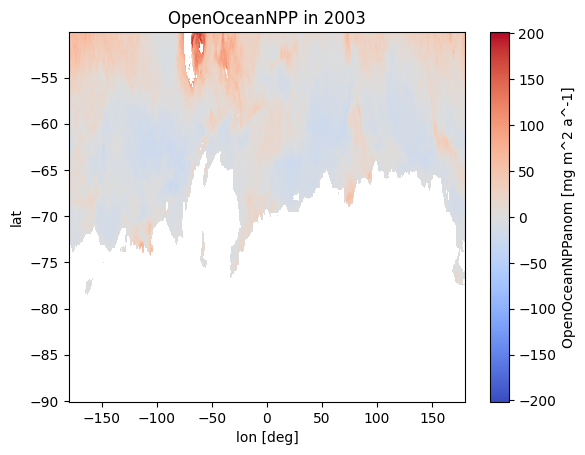

In [10]:
variable_name = "OpenOceanNPP"
data_to_plot = ds_NPP[variable_name]
print("plotted data size",data_to_plot.shape)

# Plot using xarray's built-in method
data_to_plot.isel(year=0).plot(cmap="coolwarm")
plt.title(f"{variable_name} in {float(ds_NPP.year[0].values):.0f}")
plt.show()

In [11]:
# plt.tight_layout()
# #create array with monthly average contribution to annual integrated (summed) NNP
# ann_NPP = ds_NPP['OpenOceanNPP'].values
# monthly_NPP = np.repeat(ann_NPP / 12, repeats=12, axis=0)
# print(len(ann_NPP), len(monthly_NPP))
# # #select appropriate times - match to dot length/extent
# # monthly_NPP = monthly_NPP[tstart_NPP:tend_NPP]
# # print(len(monthly_NPP))

In [12]:
# print(ds_NPP.dims)
# print(ds_NPP['OpenOceanNPP'].shape)
# print(ann_NPP.shape)
# print(monthly_NPP.shape)

In [13]:
# #add monthly dates and NPP values to ds_NPP
# ds_NPP['monthly_NPP']= (('monthly_NPP_time', 'lon', 'lat'), monthly_NPP)
# ds_NPP = ds.assign_coords(monthly_NPP_time = ('monthly_NPP_time', monthly_NPP_time))
# print(ds_NPP)

In [14]:
# change coordinates from (lon,lat,time) to (time,lat,lon) as ERA5
lon = ds['longitude'].values; lat = ds['latitude'].values
dot_all = ds['dot'].values
dot = np.zeros((dot_all.shape[2], dot_all.shape[1], dot_all.shape[0]))
for t in range(0,dot_all.shape[2]):
    for i in range(0,dot_all.shape[1]):
        for j in range(0,dot_all.shape[0]):
            dot[t,i,j] = dot_all[j,i,t].copy()
seamask = dot[0].copy()/dot[0]
seamask[seamask == 0] = np.nan
del dot_all

In [15]:
# make lon lat 2d
llon = np.zeros((dot.shape[1],dot.shape[2]))
for i in range(0,dot.shape[1]):
    llon[i,:] = lon
llat = np.zeros((dot.shape[1],dot.shape[2]))
for i in range(0,dot.shape[2]):
    llat[:,i] = lat

In [16]:
dot.shape

(196, 64, 360)

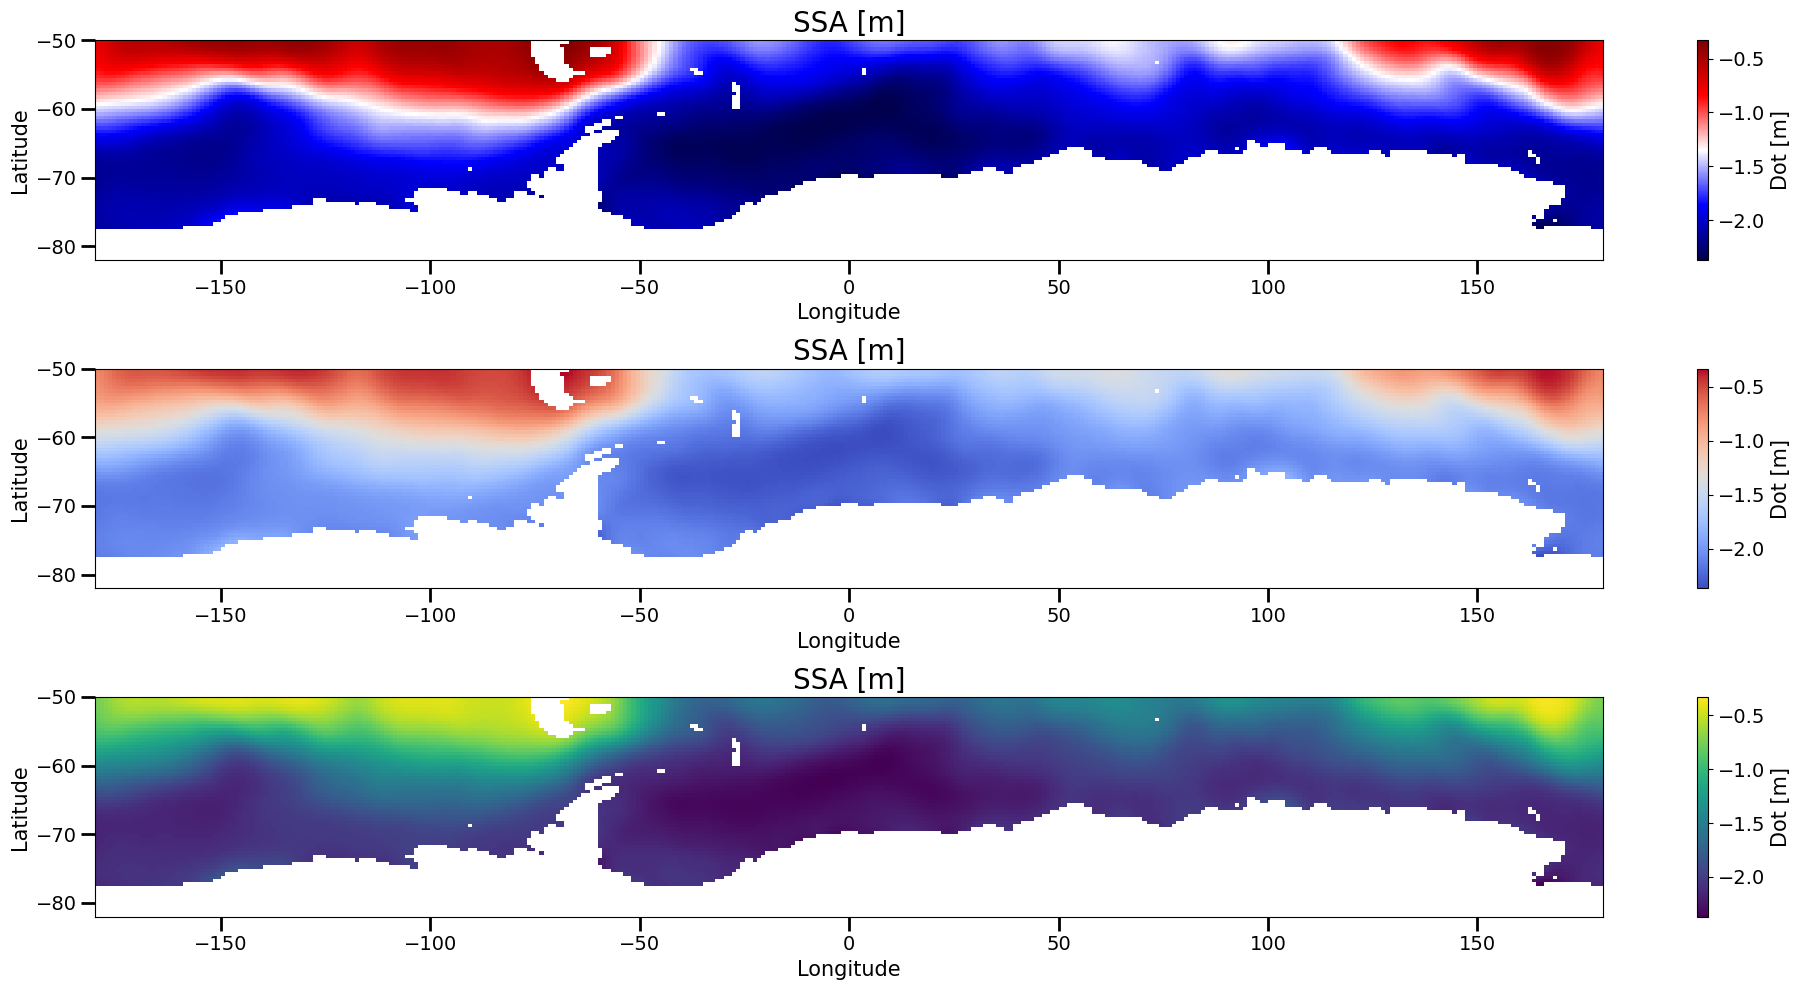

In [17]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(20, 10))

pc1 = axes[0].pcolormesh(llon,llat,dot[0], cmap='seismic')
axes[0].tick_params(axis='both', which='major', length=10, width=2, labelsize=14)
axes[0].set_title('SSA [m]', fontsize=20)
axes[0].set_xlabel('Longitude', fontsize=15)
axes[0].set_ylabel('Latitude', fontsize=15)
cbar1 = fig.colorbar(pc1, ax=axes[0])
cbar1.set_label('Dot [m]', fontsize=15)
cbar1.ax.tick_params(labelsize=14)

pc2 = axes[1].pcolormesh(llon,llat,dot[0], cmap='coolwarm')
axes[1].tick_params(axis='both', which='major', length=10, width=2, labelsize=14)
axes[1].set_title('SSA [m]', fontsize=20)
axes[1].set_xlabel('Longitude', fontsize=15)
axes[1].set_ylabel('Latitude', fontsize=15)
cbar2 = fig.colorbar(pc2, ax=axes[1])
cbar2.set_label('Dot [m]', fontsize=15)
cbar2.ax.tick_params(labelsize=14)

pc3 = axes[2].pcolormesh(llon,llat,dot[0], cmap='viridis')
axes[2].tick_params(axis='both', which='major', length=10, width=2, labelsize=14)
axes[2].set_title('SSA [m]', fontsize=20)
axes[2].set_xlabel('Longitude', fontsize=15)
axes[2].set_ylabel('Latitude', fontsize=15)
cbar3 = fig.colorbar(pc3, ax=axes[2])
cbar3.set_label('Dot [m]', fontsize=15)
cbar3.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.show()

In [18]:
# total_nans = dot_xa.isnull().sum().item()
# print(f"Total NaN values in dot_xa: {total_nans}")


In [19]:
# time
time_era5 = ds_era5['time'].values
time_dot = ds['time'].values
time_NPP = ds_NPP['year'].values

In [20]:
#create new NPP dates where they are monthly (not annual)
start_year = int(time_NPP[0])
end_year = int(time_NPP[-1])
monthly_NPP_time = pd.date_range(start=f'{start_year}',end=f'{end_year}', freq='MS')
monthly_NPP_time = monthly_NPP_time.strftime('%Y-%m-%dT%H:%M:%S.%f000')
print(monthly_NPP_time)

Index(['2003-01-01T00:00:00.000000000', '2003-02-01T00:00:00.000000000',
       '2003-03-01T00:00:00.000000000', '2003-04-01T00:00:00.000000000',
       '2003-05-01T00:00:00.000000000', '2003-06-01T00:00:00.000000000',
       '2003-07-01T00:00:00.000000000', '2003-08-01T00:00:00.000000000',
       '2003-09-01T00:00:00.000000000', '2003-10-01T00:00:00.000000000',
       ...
       '2023-04-01T00:00:00.000000000', '2023-05-01T00:00:00.000000000',
       '2023-06-01T00:00:00.000000000', '2023-07-01T00:00:00.000000000',
       '2023-08-01T00:00:00.000000000', '2023-09-01T00:00:00.000000000',
       '2023-10-01T00:00:00.000000000', '2023-11-01T00:00:00.000000000',
       '2023-12-01T00:00:00.000000000', '2024-01-01T00:00:00.000000000'],
      dtype='object', length=253)


In [21]:
#print(time_era5)
print(time_dot[6],time_dot[-1])
print(time_era5[36],time_era5[225])
print(monthly_NPP_time[0],monthly_NPP_time[189])

2003-01-01T00:00:00.000000000 2018-10-01T00:00:00.000000000
2003-01-01T00:00:00.000000000 2018-10-01T00:00:00.000000000
2003-01-01T00:00:00.000000000 2018-10-01T00:00:00.000000000


In [47]:
tstart_dot = 6
tend_dot = -1
tstart_era5_NPP = 36
tstart_era5 = 30
tend_era5 = 226 # +1 respect cell above
tstart_NPP = 0
tend_NPP = 190 #+1 wrt cell above

In [48]:
# select wind
u10 = ds_era5['u10'][tstart_era5:tend_era5].values
v10 = ds_era5['v10'][tstart_era5:tend_era5].values

# map lat in lat[::-1] when using gridboxmean mapping
# since lat in ERA5 goes from -50 to -80 instead in dot goes from -80 to -50
if gridtype == 'gridboxmean':
    print('you are using ',gridtype)
    u10 = u10[:,::-1,:]  
    v10 = v10[:,::-1,:]  
    
u10 = u10*seamask
v10 = v10*seamask
U = np.sqrt(u10**2. + v10**2.)

In [49]:
# wind stress
tau_x = rho_a*Cd*U*u10 #zonal wind
tau_y = rho_a*Cd*U*v10 #meridional wind

print('zonal wind:', tau_x)
print('meridional wind:', tau_y)

zonal wind: [[[       nan        nan        nan ...        nan        nan        nan]
  [       nan        nan        nan ...        nan        nan        nan]
  [       nan        nan        nan ...        nan        nan        nan]
  ...
  [0.02068101 0.01995691 0.01893414 ... 0.02478185 0.02406133 0.02285532]
  [0.02073882 0.02002566 0.01897176 ... 0.02542477 0.02491941 0.02391698]
  [0.02081135 0.01977531 0.01851727 ... 0.02508504 0.02510456 0.0242639 ]]

 [[       nan        nan        nan ...        nan        nan        nan]
  [       nan        nan        nan ...        nan        nan        nan]
  [       nan        nan        nan ...        nan        nan        nan]
  ...
  [0.02263992 0.02283532 0.02308318 ... 0.0202767  0.02100487 0.02146125]
  [0.01919219 0.01941123 0.01973684 ... 0.01726765 0.01758919 0.01786926]
  [0.01712514 0.01781618 0.01820304 ... 0.01602753 0.01570514 0.01575291]]

 [[       nan        nan        nan ...        nan        nan        nan]
  [       

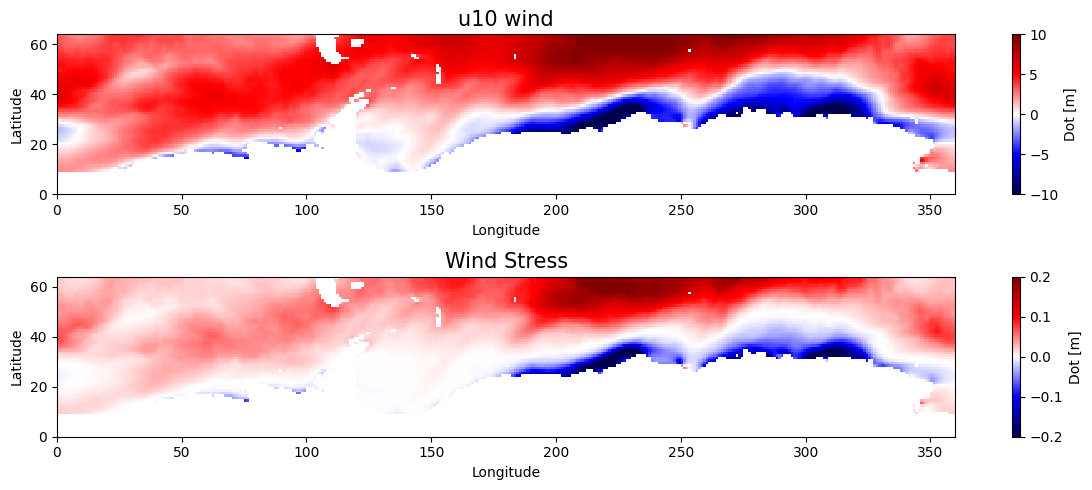

In [50]:
fig = plt.figure(figsize=(12,5))
plt.subplot(2,1,1)
plt.pcolormesh(u10[0],cmap='seismic',vmin=-10,vmax=10)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('u10 wind', fontsize=15)
cbar1= plt.colorbar()
cbar1.set_label('Dot [m]')
plt.subplot(2,1,2)
plt.pcolormesh(tau_x[0],cmap='seismic',vmin=-0.2,vmax=0.2)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Wind Stress', fontsize=15)
cbar2= plt.colorbar()
cbar2.set_label('Dot [m]')


plt.tight_layout()


In [51]:
print(tau_x.shape)

(196, 64, 360)


In [52]:
# wind stress curl
ws_curl = np.zeros(tau_x.shape)
for t in range(0,u10.shape[0]):
    dtaux_dx, dtaux_dy = grad_sphere(tau_x[t], llon, llat)
    dtauy_dx, dtauy_dy = grad_sphere(tau_y[t], llon, llat)
    ws_curl[t] = dtauy_dx - dtaux_dy

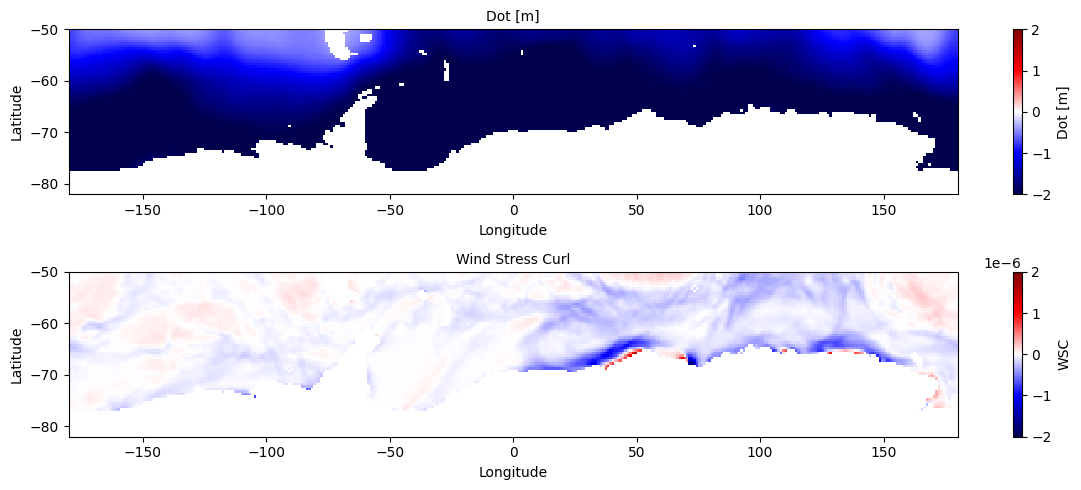

In [53]:
fig = plt.figure(figsize=(12,5))
plt.subplot(2,1,1)
plt.pcolormesh(llon, llat, dot[0], vmin=-2, vmax=2, cmap='seismic')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Dot [m]', fontsize=10)
ws1bar = plt.colorbar()
ws1bar.set_label('Dot [m]')

plt.subplot(2,1,2)
plt.pcolormesh(llon, llat, ws_curl[0], vmin=-2e-6, vmax=2e-6, cmap='seismic')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Wind Stress Curl', fontsize=10)
#plt.quiver(llon, llat, u10[0], v10[0])
ws2bar = plt.colorbar()
ws2bar.set_label('WSC')

plt.tight_layout()

In [54]:
#create array with monthly average contribution to annual integrated (summed) NNP
ann_NPP = ds_NPP['OpenOceanNPP'].values
monthly_NPP = np.repeat(ann_NPP/12, repeats = 12, axis = 0)
print(len(ann_NPP), len(monthly_NPP))
# #select appropriate times - match to dot length/extent
# monthly_NPP = monthly_NPP[tstart_NPP:tend_NPP]
# print(len(monthly_NPP))

22 264


In [55]:
print(ds_NPP.dims)
print(ds_NPP['OpenOceanNPP'].shape)
print(ann_NPP.shape)
print(monthly_NPP.shape)

FrozenMappingWarningOnValuesAccess({'year': 22, 'lat': 480, 'lon': 4320, 'monthly_NPP_time': 253, 'lat_NPP': 480, 'lon_NPP': 4320})
(22, 480, 4320)
(22, 480, 4320)
(264, 480, 4320)


In [56]:
print(ds_NPP)

<xarray.Dataset> Size: 5GB
Dimensions:           (year: 22, lat: 480, lon: 4320, monthly_NPP_time: 253,
                       lat_NPP: 480, lon_NPP: 4320)
Coordinates:
  * lat               (lat) float64 4kB -90.04 -89.96 -89.87 ... -50.21 -50.12
  * lon               (lon) float64 35kB -179.9 -179.8 -179.7 ... 180.0 180.0
  * year              (year) float64 176B 2.003e+03 2.004e+03 ... 2.024e+03
  * monthly_NPP_time  (monthly_NPP_time) object 2kB '2003-01-01T00:00:00.0000...
Dimensions without coordinates: lat_NPP, lon_NPP
Data variables:
    OpenOceanNPP      (year, lat, lon) float64 365MB 0.0 0.0 0.0 ... 15.99 0.0
    monthly_NPP       (monthly_NPP_time, lat_NPP, lon_NPP) float64 4GB 0.0 .....


In [57]:
#add monthly dates and NPP values to ds_NPP
lon_NPP = ds_NPP['lon'].values
lat_NPP = ds_NPP['lat'].values
ds_NPP['monthly_NPP']= (('monthly_NPP_time', 'lat_NPP', 'lon_NPP'), monthly_NPP[0:-11])
ds_NPP = ds_NPP.assign_coords(monthly_NPP_time = ('monthly_NPP_time', monthly_NPP_time))
ds_NPP = ds_NPP.fillna(0)

print(ds_NPP)

<xarray.Dataset> Size: 5GB
Dimensions:           (year: 22, lat: 480, lon: 4320, monthly_NPP_time: 253,
                       lat_NPP: 480, lon_NPP: 4320)
Coordinates:
  * lat               (lat) float64 4kB -90.04 -89.96 -89.87 ... -50.21 -50.12
  * lon               (lon) float64 35kB -179.9 -179.8 -179.7 ... 180.0 180.0
  * year              (year) float64 176B 2.003e+03 2.004e+03 ... 2.024e+03
  * monthly_NPP_time  (monthly_NPP_time) object 2kB '2003-01-01T00:00:00.0000...
Dimensions without coordinates: lat_NPP, lon_NPP
Data variables:
    OpenOceanNPP      (year, lat, lon) float64 365MB 0.0 0.0 0.0 ... 15.99 0.0
    monthly_NPP       (monthly_NPP_time, lat_NPP, lon_NPP) float64 4GB 0.0 .....


In [58]:
# DE-TREND
dot.shape

(196, 64, 360)

In [59]:
# linear regression in time on each grid point
n,slope,intercept,p_val,r_square,rmse = linregress_3D(dot)
# remove trend for dot
xt = np.zeros(dot.shape)
for t in range(0,dot.shape[0]):
    xt[t] = t
dot_detrended = dot - (slope*xt + intercept)

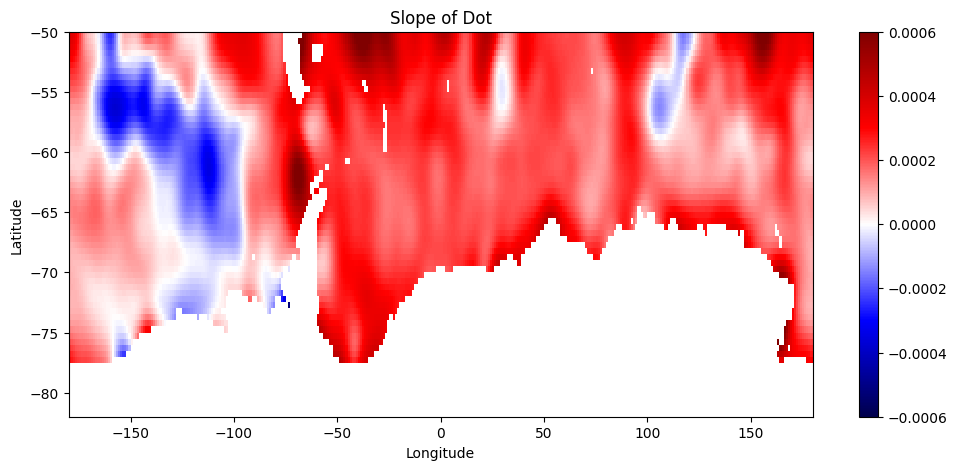

In [60]:
plt.figure(figsize=(12,5))
plt.pcolormesh(lon, lat, slope, vmin=-6e-4, vmax=6e-4, cmap='seismic')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Slope of Dot')
plt.colorbar()


In [61]:
# linear regression in time on each grid point
n,slope,intercept,p_val,r_square,rmse = linregress_3D(ws_curl)
# remove trend for ws_curl
xt = np.zeros(ws_curl.shape)
for t in range(0,ws_curl.shape[0]):
    xt[t] = t
ws_curl_detrended = ws_curl - (slope*xt + intercept)

In [62]:
#dot_final = dot_detrended.copy()
#ws_curl_final = ws_curl_detrended.copy()

In [63]:
# DE-SEASONAL

In [64]:
months = time_dot.astype('datetime64[M]').astype(int) % 12 + 1
print(months)

[ 7  8  9 10 11 12  1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6
  7  8  9 10 11 12  1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6
  7  8  9 10 11 12  1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6
  7  8  9 10 11 12  1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6
  7  8  9 10 11 12  1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6
  7  8  9 10 11 12  1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6
  7  8  9 10 11 12  1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6
  7  8  9 10 11 12  1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6
  7  8  9 10]


In [65]:
print("months shape:", months.shape)
print("ws_curl_detrended shape:", ws_curl_detrended.shape)
print('dot detreneded shape', dot_detrended.shape)

months shape: (196,)
ws_curl_detrended shape: (196, 64, 360)
dot detreneded shape (196, 64, 360)


In [66]:
# find and remove seasonality from dot_detrended and ws_curl_detrended
dot_seas = np.zeros((12,dot.shape[1],dot.shape[2])); ws_curl_seas = np.zeros((12,dot.shape[1],dot.shape[2]))
for m in range(1,13):
    dot_seas[m-1] = np.nanmean(dot_detrended[np.where(months==m)], axis=0)
    ws_curl_seas[m-1] = np.nanmean(ws_curl_detrended[np.where(months==m)], axis=0)

# remove seasonality
dot_final = np.zeros(dot_detrended.shape); ws_curl_final = np.zeros(ws_curl_detrended.shape)
for i,m in enumerate(months):
    dot_final[i] = dot_detrended[i] - dot_seas[m-1]
    ws_curl_final[i] = ws_curl_detrended[i] - ws_curl_seas[m-1]

In [67]:
print(dot.shape)
print(dot[0])
# print(dot[1])
# print(dot[2])

(196, 64, 360)
[[        nan         nan         nan ...         nan         nan
          nan]
 [        nan         nan         nan ...         nan         nan
          nan]
 [        nan         nan         nan ...         nan         nan
          nan]
 ...
 [-0.75397619 -0.73751731 -0.71145781 ... -0.71390379 -0.74343705
  -0.75675648]
 [-0.74548579 -0.72969073 -0.70308686 ... -0.69892569 -0.73085478
  -0.74653662]
 [-0.74081023 -0.72535831 -0.69847726 ... -0.69097384 -0.7240913
  -0.74097281]]


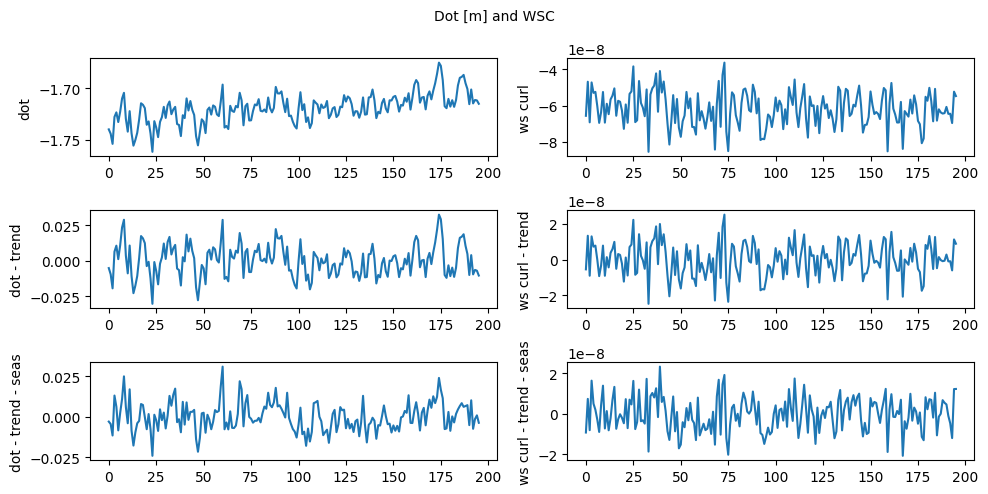

In [68]:
fig = plt.figure(figsize=(10,5))
plt.subplot(3,2,1)
plt.plot(np.nanmean(dot, axis=(1,2)))
plt.ylabel('dot')
plt.subplot(3,2,2)
plt.plot(np.nanmean(ws_curl, axis=(1,2)))
plt.ylabel('ws curl')
plt.subplot(3,2,3)
plt.plot(np.nanmean(dot_detrended, axis=(1,2)))
plt.ylabel('dot - trend')
plt.subplot(3,2,4)
plt.plot(np.nanmean(ws_curl_detrended, axis=(1,2)))
plt.ylabel('ws curl - trend')
plt.subplot(3,2,5)
plt.plot(np.nanmean(dot_final, axis=(1,2)))
plt.ylabel('dot - trend - seas')
plt.subplot(3,2,6)
plt.plot(np.nanmean(ws_curl_final, axis=(1,2)))
plt.ylabel('ws curl - trend - seas')
plt.suptitle('Dot [m] and WSC', fontsize=10)

plt.tight_layout()

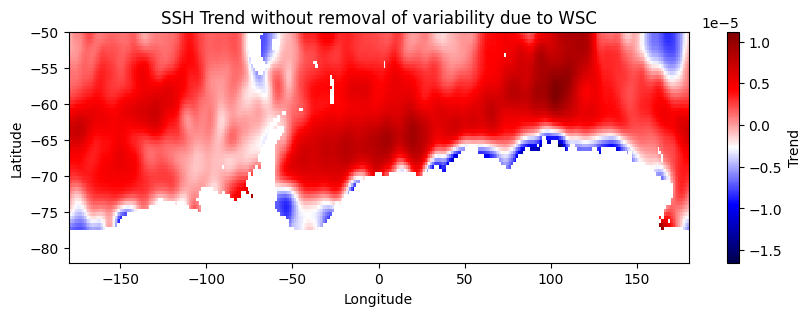

In [69]:
# SSH trends without removing ocean variability due to wind stress curl
plt.figure(figsize=(10,3))
n,slope,intercept,p_val,r_square,rmse = linregress_3D(dot_final)
plt.pcolormesh(lon, lat, slope, cmap='seismic')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('SSH Trend without removal of variability due to WSC')
cbar = plt.colorbar()
cbar.set_label('Trend')

In [75]:
print(dot_final[tstart_dot::].shape)
print(ds['latitude'].shape)
print(ds_NPP['monthly_NPP'][tstart_NPP:tend_NPP].shape)
print(ws_curl_final[6::].shape)


(190, 64, 360)
(64,)
(190, 480, 4320)
(190, 64, 360)


In [76]:
from scipy.interpolate import griddata

#regrid SSH to match NPP
ssh_data = dot_final[tstart_dot::]
source_lat = ds['latitude'].values
source_lon = ds['longitude'].values

print(source_lat.shape)
print(source_lon.shape)

source_lon2d, source_lat2d = np.meshgrid(source_lon, source_lat)
source_points = np.column_stack((source_lat2d.ravel(), source_lon2d.ravel()))

target_lat = ds_NPP['lat'].values
target_lon = ds_NPP['lon'].values

print(target_lat.shape)
print(target_lon.shape)

target_lon2d, target_lat2d = np.meshgrid(target_lon, target_lat)
target_points = np.column_stack((target_lat2d.ravel(), target_lon2d.ravel()))

num_times = ssh_data.shape[0]
regridded_ssh = np.empty((num_times, len(target_lat), len(target_lon)))

# Loop over time
for t in range(num_times):
    print(f"Regridding time step {t + 1}/{num_times}...")

    # Flatten SSH data at time t and interpolate to target grid
    values = ssh_data[t].ravel()
    interpolated = griddata(source_points, values, target_points, method='linear')

    # Reshape the interpolated values back to the target grid

    regridded_ssh[t] = interpolated.reshape((len(target_lat), len(target_lon)))


(64,)
(360,)
(480,)
(4320,)
Regridding time step 1/190...
Regridding time step 2/190...
Regridding time step 3/190...
Regridding time step 4/190...
Regridding time step 5/190...
Regridding time step 6/190...
Regridding time step 7/190...
Regridding time step 8/190...
Regridding time step 9/190...
Regridding time step 10/190...
Regridding time step 11/190...
Regridding time step 12/190...
Regridding time step 13/190...
Regridding time step 14/190...
Regridding time step 15/190...
Regridding time step 16/190...
Regridding time step 17/190...
Regridding time step 18/190...
Regridding time step 19/190...
Regridding time step 20/190...
Regridding time step 21/190...
Regridding time step 22/190...
Regridding time step 23/190...
Regridding time step 24/190...
Regridding time step 25/190...
Regridding time step 26/190...
Regridding time step 27/190...
Regridding time step 28/190...
Regridding time step 29/190...
Regridding time step 30/190...
Regridding time step 31/190...
Regridding time step

In [77]:
print(regridded_ssh.shape)
print(monthly_NPP[tstart_NPP:tend_NPP].shape)

(190, 480, 4320)
(190, 480, 4320)


In [78]:
from scipy.interpolate import griddata

#regrid SSH to match NPP
wsc_data = ws_curl_final[6::]
source_lat = ds['latitude'].values
source_lon = ds['longitude'].values

print(source_lat.shape)
print(source_lon.shape)

source_lon2d, source_lat2d = np.meshgrid(source_lon, source_lat)
source_points = np.column_stack((source_lat2d.ravel(), source_lon2d.ravel()))

target_lat = ds_NPP['lat'].values
target_lon = ds_NPP['lon'].values

print(target_lat.shape)
print(target_lon.shape)

target_lon2d, target_lat2d = np.meshgrid(target_lon, target_lat)
target_points = np.column_stack((target_lat2d.ravel(), target_lon2d.ravel()))

num_times = wsc_data.shape[0]
regridded_wsc = np.empty((num_times, len(target_lat), len(target_lon)))

# Loop over time
for t in range(num_times):
    print(f"Regridding time step {t + 1}/{num_times}...")

    # Flatten SSH data at time t and interpolate to target grid
    values = wsc_data[t].ravel()
    interpolated = griddata(source_points, values, target_points, method='linear')

    # Reshape the interpolated values back to the target grid

    regridded_wsc[t] = interpolated.reshape((len(target_lat), len(target_lon)))


(64,)
(360,)
(480,)
(4320,)
Regridding time step 1/190...
Regridding time step 2/190...
Regridding time step 3/190...
Regridding time step 4/190...
Regridding time step 5/190...
Regridding time step 6/190...
Regridding time step 7/190...
Regridding time step 8/190...
Regridding time step 9/190...
Regridding time step 10/190...
Regridding time step 11/190...
Regridding time step 12/190...
Regridding time step 13/190...
Regridding time step 14/190...
Regridding time step 15/190...
Regridding time step 16/190...
Regridding time step 17/190...
Regridding time step 18/190...
Regridding time step 19/190...
Regridding time step 20/190...
Regridding time step 21/190...
Regridding time step 22/190...
Regridding time step 23/190...
Regridding time step 24/190...
Regridding time step 25/190...
Regridding time step 26/190...
Regridding time step 27/190...
Regridding time step 28/190...
Regridding time step 29/190...
Regridding time step 30/190...
Regridding time step 31/190...
Regridding time step

In [79]:
# MCA

In [80]:
lat = ds_NPP['lat'].values
lon = ds_NPP['lon'].values

regridded_ssh = np.nan_to_num(regridded_ssh, nan=0)
selected_NPP = np.nan_to_num(monthly_NPP[tstart_NPP:tend_NPP], nan=0)
regridded_wsc = np.nan_to_num(regridded_wsc, nan=0)

dot_xa = xr.DataArray(regridded_ssh, coords=[time_dot[tstart_dot::], lat, lon], dims=["time", "lon", "lat"],)
ws_curl_xa = xr.DataArray(regridded_wsc, coords=[time_dot[tstart_dot::], lat, lon], dims=["time", "lon", "lat"],)
NPP_xa = xr.DataArray(selected_NPP, coords = [time_dot[tstart_dot::], lat, lon], dims=["time", "lon", "lat"],)

In [82]:
total_nans = dot_xa.isnull().sum().item()
print(f"Total NaN values in dot_xa: {total_nans}")
total_points_dot = dot_xa.size
print(f"Total data points in dot_xa: {total_points_dot}")

total_nans_wsc = ws_curl_xa.isnull().sum().item()
print(f"Total NaN values in wsc: {total_nans_wsc}")
total_points_wsc = ws_curl_xa.size
print(f"Total data points in wsc: {total_points_wsc}")

total_nans_NPP = NPP_xa.isnull().sum().item()
print(f"Total NaN values in NPP_xa: {total_nans_NPP}")
total_points_NPP = NPP_xa.size
print(f"Total data points in NPP_xa: {total_points_NPP}")

Total NaN values in dot_xa: 0
Total data points in dot_xa: 393984000
Total NaN values in wsc: 0
Total data points in wsc: 393984000
Total NaN values in NPP_xa: 0
Total data points in NPP_xa: 393984000


In [83]:
print(dir(xe))


['RotatorFactory', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', '_version', 'base_model', 'cross', 'data_container', 'linalg', 'multi', 'preprocessing', 'rotator_factory', 'single', 'utils', 'validation']


In [107]:
import inspect
model = xe.cross.MCA(n_modes=15, standardize=True)
#print(dir(model))

print(dot_xa.coords)

print(dir(model))
print(dot_xa.dims)
#print(ws_curl_xa.dims)
# model.fit(dot_xa, ws_curl_xa, dim='time')
model.fit(dot_xa, NPP_xa, dim='time')
comps1, comps2 = model.components()  # Singular vectors (spatial patterns)
scores1, scores2 = model.scores()  # Expansion coefficients (temporal patterns)

Coordinates:
  * time     (time) datetime64[ns] 2kB 2003-01-01 2003-02-01 ... 2018-10-01
  * lon      (lon) float64 4kB -90.04 -89.96 -89.87 ... -50.29 -50.21 -50.12
  * lat      (lat) float64 35kB -179.9 -179.8 -179.7 ... 179.9 180.0 180.0
['__abstractmethods__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_augment_data', '_check_parameter_number', '_compute_cross_covariance_diagonal_numpy', '_compute_cross_covariance_numpy', '_compute_cross_matrix', '_compute_total_squared_covariance', '_compute_total_variance', '_covariance_explained_DC95', '_decomposer_kwargs', '_deserialize_attrs', '_fit_algorithm', '_get_components', '_get_scores', '_inverse_t

In [108]:
s1 = scores1.values; s2 = scores2.values
c1 = comps1.values; c2 = comps2.values

In [109]:
print(path)
print(gridtype)

/Users/iw2g24/PycharmProjects/SSH_project/
remapcon


In [110]:
# Full path to the 'results' directory
results_dir = os.path.join(path, 'results')

# Check if the directory already exists
if os.path.exists(results_dir):
    print("Directory already exists")
else:
    # Create the directory if it doesn't exist
    os.makedirs(results_dir, exist_ok=True)
    print("Directory created!")

Directory already exists


In [111]:
# # write PCs on files
# # fname = path + 'results/PCs_dot_' + gridtype + '.txt'
# fname = path + 'results/PCs_dot_' + gridtype + '_seas.txt'
# with open(fname, 'w') as file:
#     file.write('time\tPC1\tPC2\tPC3\n')
#     for i in range(len(time_dot)):
#         file.write(f'{time_dot[i]}\t{s1[0,i]}\t{s1[1,i]}\t{s1[2,i]}\n')
# file.close()
#
# # fname = path + 'results/PCs_ws_curl_' + gridtype + '.txt'
# fname = path + 'results/PCs_ws_curl_' + gridtype + '_seas.txt'
# with open(fname, 'w') as file:
#     file.write('time\tPC1\tPC2\tPC3\n')
#     for i in range(len(time_dot)):
#         file.write(f'{time_dot[i]}\t{s2[0,i]}\t{s2[1,i]}\t{s2[2,i]}\n')
# file.close()

In [112]:
#how can you change from using cross.MCA to calling the subplots PCA1, PCA2, PCA3 etc ...

In [113]:
r_pears = []; p_pears = []
r_spear = []; p_spear = []
for m in range(1,5):
    x = scores1.sel(mode=m)
    y = scores2.sel(mode=m)
    r, p = scipy.stats.pearsonr(x, y)
    r_pears.append(np.round(r, 2)); p_pears.append(np.round(p, 2))
    r, p = scipy.stats.spearmanr(x, y)
    r_spear.append(np.round(r, 2)); p_spear.append(np.round(p, 2))

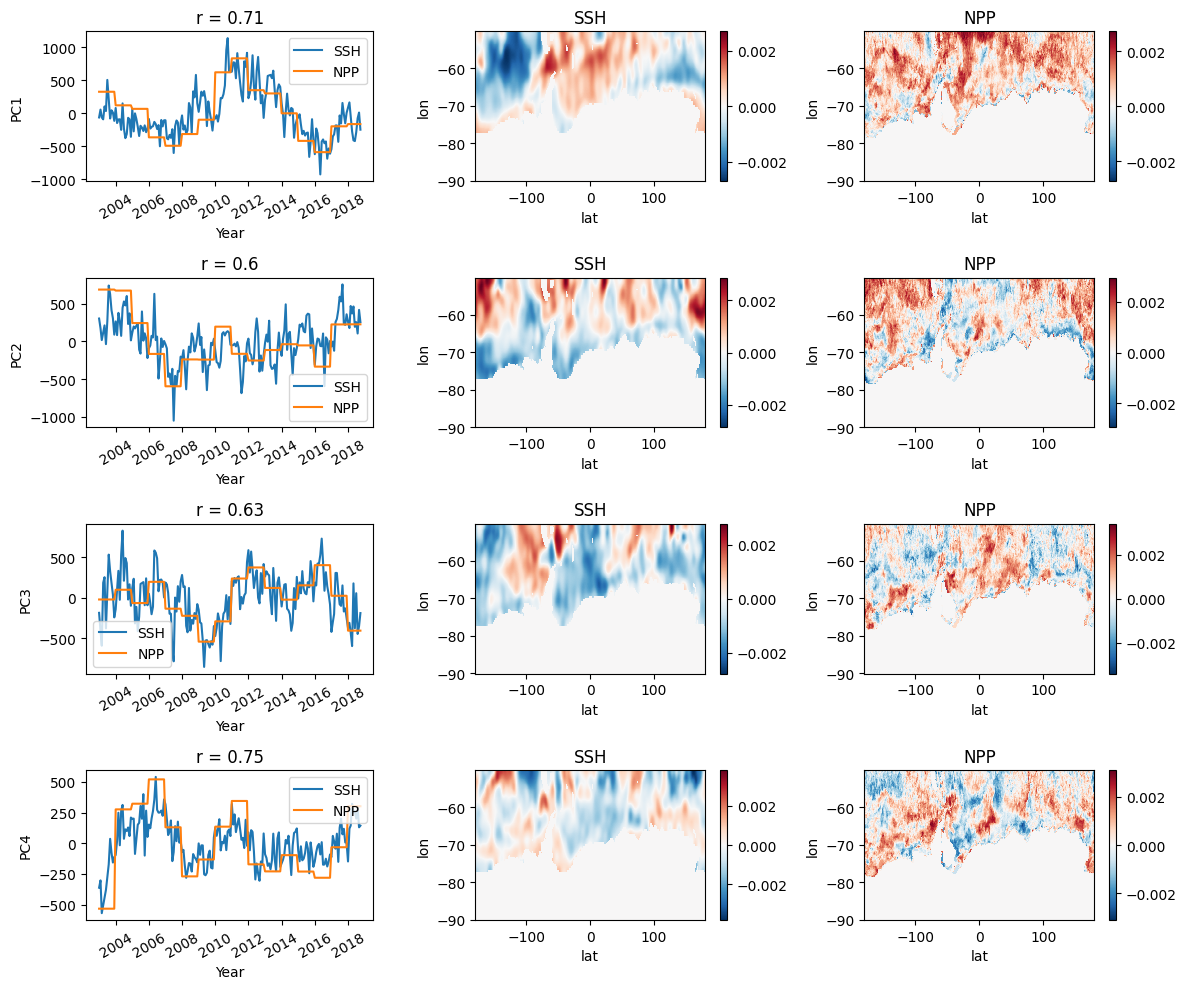

In [114]:
fig = plt.figure(figsize=(12,10))

for i in range(0,4):
    j = 3*i+1 # a = 2*(i+1) + i - 1
    
    plt.subplot(4,3,j)
    scores1.sel(mode=i+1).plot(label = 'SSH')
    scores2.sel(mode=i+1).plot(label = 'NPP')
    plt.title('r = ' +str(r_spear[i]))
    plt.xlabel('Year'); plt.ylabel('PC'+str(int(i+1)))
    plt.xticks(rotation=30) 
    plt.legend()
    
    plt.subplot(4,3,j+1)
    comps1.sel(mode=i+1).plot()
    plt.title('SSH')
    
    plt.subplot(4,3,j+2)
    comps2.sel(mode=i+1).plot()
    plt.title('NPP')

fig.tight_layout()

# fig.savefig(path + 'results/MCA_output_' + gridtype + '_seas.png')

In [115]:
# compute squared covariance fraction (equivalent to explained variance in PCA)
sq_cov_frac = model.squared_covariance_fraction()
scf = sq_cov_frac.values
cum_sum = np.cumsum(scf)
print('Cumulative sum of squares:', cum_sum)
print('Squared covariance fraction:',scf)

Cumulative sum of squares: [0.45804465 0.60570089 0.71826285 0.78202435 0.84446181 0.87620502
 0.90221455 0.92547787 0.94224833 0.95754075 0.97154748 0.9817301
 0.99031594 0.99853415 1.        ]
Squared covariance fraction: [0.45804465 0.14765624 0.11256196 0.0637615  0.06243746 0.03174322
 0.02600952 0.02326332 0.01677047 0.01529241 0.01400673 0.01018261
 0.00858584 0.00821821 0.00146585]


In [116]:
print(type(cum_sum))
print(len(cum_sum))
mode_percent = []
for i in range(len(cum_sum)):
    if i == 0:
        each_mode_percent =float(cum_sum[i])
        mode_percent.append(each_mode_percent)
    else:
        each_mode_percent = float(cum_sum[i]-cum_sum[i-1])
        mode_percent.append(each_mode_percent)
print('PCA fraction', mode_percent)


<class 'numpy.ndarray'>
15
PCA fraction [0.45804464645967313, 0.14765623937505346, 0.11256196133607044, 0.0637614995785224, 0.06243745989297511, 0.03174321671448921, 0.026009522258122808, 0.023263319719247, 0.01677046946315197, 0.015292412617696427, 0.014006733335085841, 0.010182614914469257, 0.008585844084180172, 0.008218214404649316, 0.0014658458466105806]


(480, 4320)
(4320,)
(480,)


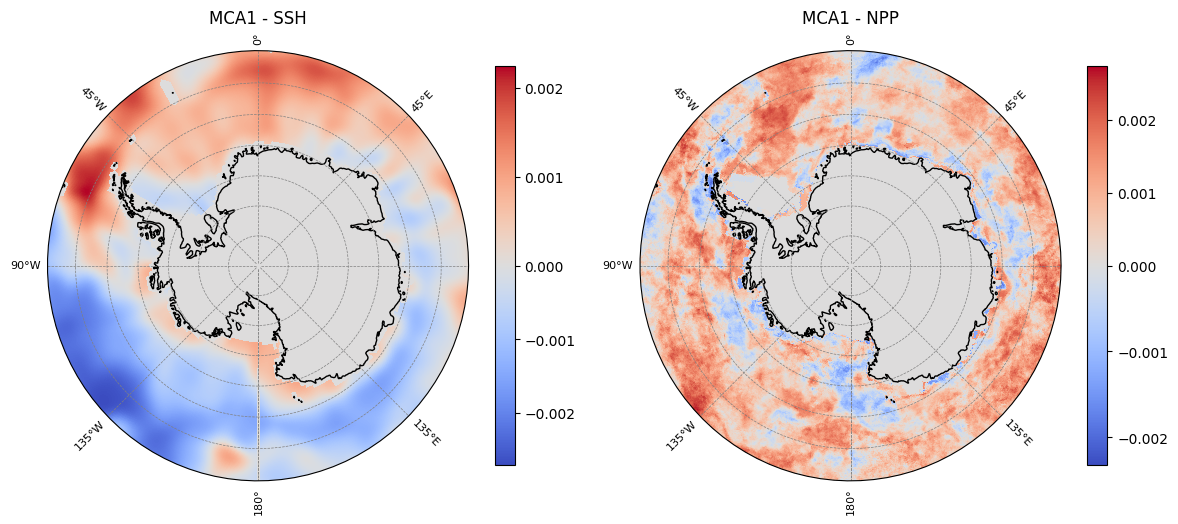

In [117]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib import colors
from polar_plot_utils import plot_curvilinear_data

# Assuming comps1 and comps2 are already defined and contain your data
comp1 = comps1.sel(mode=1)
comp2 = comps2.sel(mode=1)
lon = comp1.lat.values
lat = comp1.lon.values
data1 = comp1.values
data2 = comp2.values


print(data1.shape)
print(lon.shape)
print(lat.shape)
# Create figure and axes for two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6), subplot_kw={'projection': ccrs.SouthPolarStereo()})

# Plot data1 (Left subplot)
pc1 = plot_curvilinear_data(axes[0], data1,lon, lat, "MCA1 - SSH")

# Plot data2 (Right subplot)
pc2 = plot_curvilinear_data(axes[1], data2, lon, lat, "MCA1 - NPP")

# Add colorbars for both subplots
# fig.colorbar(pc1, ax=axes[0], orientation='vertical', label='Amplitude', shrink=0.7, pad=0.05)
# fig.colorbar(pc2, ax=axes[1], orientation='vertical', label='Amplitude', shrink=0.7, pad=0.05)

plt.tight_layout()
plt.show()


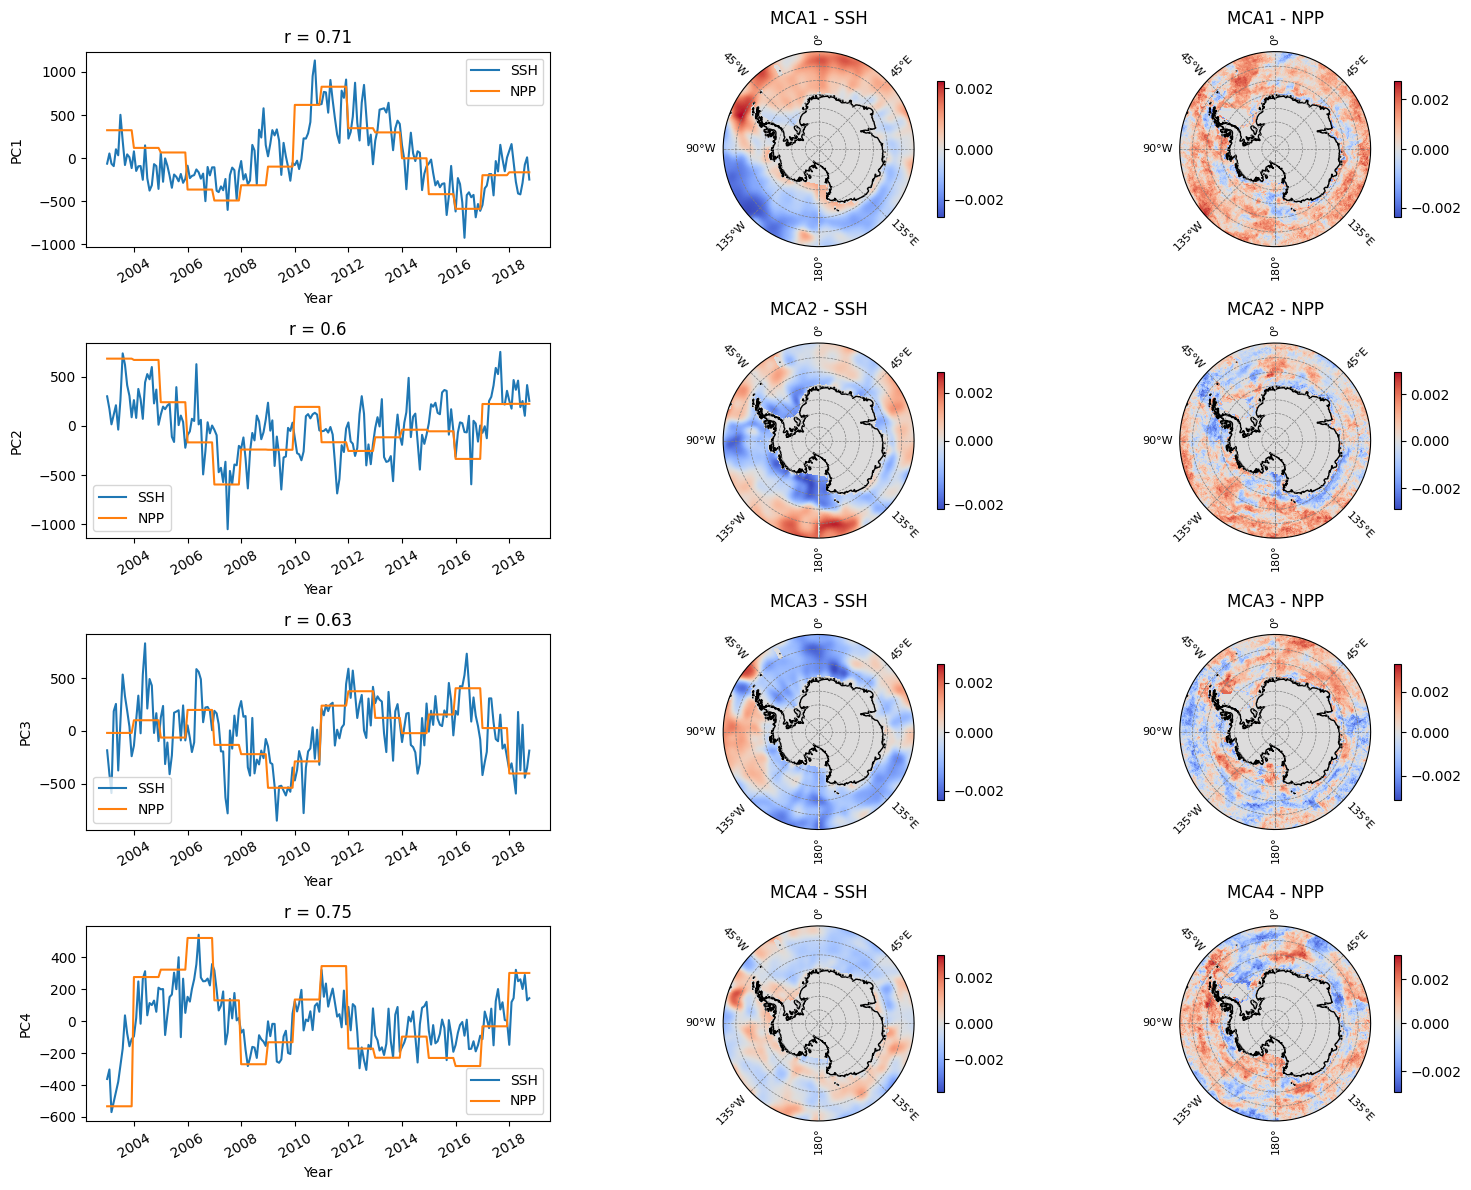

In [118]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib import colors
import scipy.stats
from matplotlib.gridspec import GridSpec

# Assuming comps1 and comps2 are already defined (MCA components)
comps1, comps2 = model.components()  # Singular vectors (spatial patterns)
scores1, scores2 = model.scores()  # Expansion coefficients (temporal patterns)
s1 = scores1.values
s2 = scores2.values
c1 = comps1.values
c2 = comps2.values


# Initialize lists for correlation coefficients
r_pears = []
p_pears = []
r_spear = []
p_spear = []

# Calculate correlation coefficients
for m in range(1, 5):
    x = scores1.sel(mode=m)
    y = scores2.sel(mode=m)
    r, p = scipy.stats.pearsonr(x, y)
    r_pears.append(np.round(r, 2))
    p_pears.append(np.round(p, 2))
    r, p = scipy.stats.spearmanr(x, y)
    r_spear.append(np.round(r, 2))
    p_spear.append(np.round(p, 2))

# Create the figure and GridSpec
fig = plt.figure(figsize=(15, 12))  # Adjust figure size to accommodate bigger columns
gs = GridSpec(4, 3, figure=fig, width_ratios=[2, 2, 2])  # Column widths: 1 for column 1, 2 for columns 2 and 3

# Loop over modes 1 to 4 and plot results
for i in range(0, 4):
    j = 3 * i  # Column position for scores plots

    # Plot scores (time series) in 1st column
    ax1 = fig.add_subplot(gs[i, 0])  # Use gs to position the subplot in the 1st column
    scores1.sel(mode=i + 1).plot(ax=ax1, label='SSH')
    scores2.sel(mode=i + 1).plot(ax=ax1, label='NPP')
    ax1.set_title('r = ' + str(r_spear[i]))
    ax1.set_xlabel('Year')
    ax1.set_ylabel('PC' + str(int(i + 1)))
    ax1.tick_params(axis='x', rotation=30)
    ax1.legend()

    # Create circular plot for SSH in 2nd column
    ax2 = fig.add_subplot(gs[i, 1], projection=ccrs.SouthPolarStereo())  # 2nd column (bigger)
    comp1 = comps1.sel(mode=i + 1)
    lon = comp1.lat.values
    lat = comp1.lon.values
    data1 = comp1.values
    plot_curvilinear_data(ax2, data1,lon, lat, "MCA" + str(i + 1) + " - SSH")

    # Create circular plot for WSC in 3rd column
    ax3 = fig.add_subplot(gs[i, 2], projection=ccrs.SouthPolarStereo())  # 3rd column (bigger)
    comp2 = comps2.sel(mode=i + 1)
    data2 = comp2.values
    plot_curvilinear_data(ax3, data2, lon,lat, "MCA" + str(i + 1) + " - NPP")

# Adjust layout to prevent overlap
fig.tight_layout()
plt.show()


Coordinates:
  * time     (time) datetime64[ns] 2kB 2003-01-01 2003-02-01 ... 2018-10-01
  * lon      (lon) float64 4kB -90.04 -89.96 -89.87 ... -50.29 -50.21 -50.12
  * lat      (lat) float64 35kB -179.9 -179.8 -179.7 ... 179.9 180.0 180.0
['__abstractmethods__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_augment_data', '_check_parameter_number', '_compute_cross_covariance_diagonal_numpy', '_compute_cross_covariance_numpy', '_compute_cross_matrix', '_compute_total_squared_covariance', '_compute_total_variance', '_covariance_explained_DC95', '_decomposer_kwargs', '_deserialize_attrs', '_fit_algorithm', '_get_components', '_get_scores', '_inverse_t

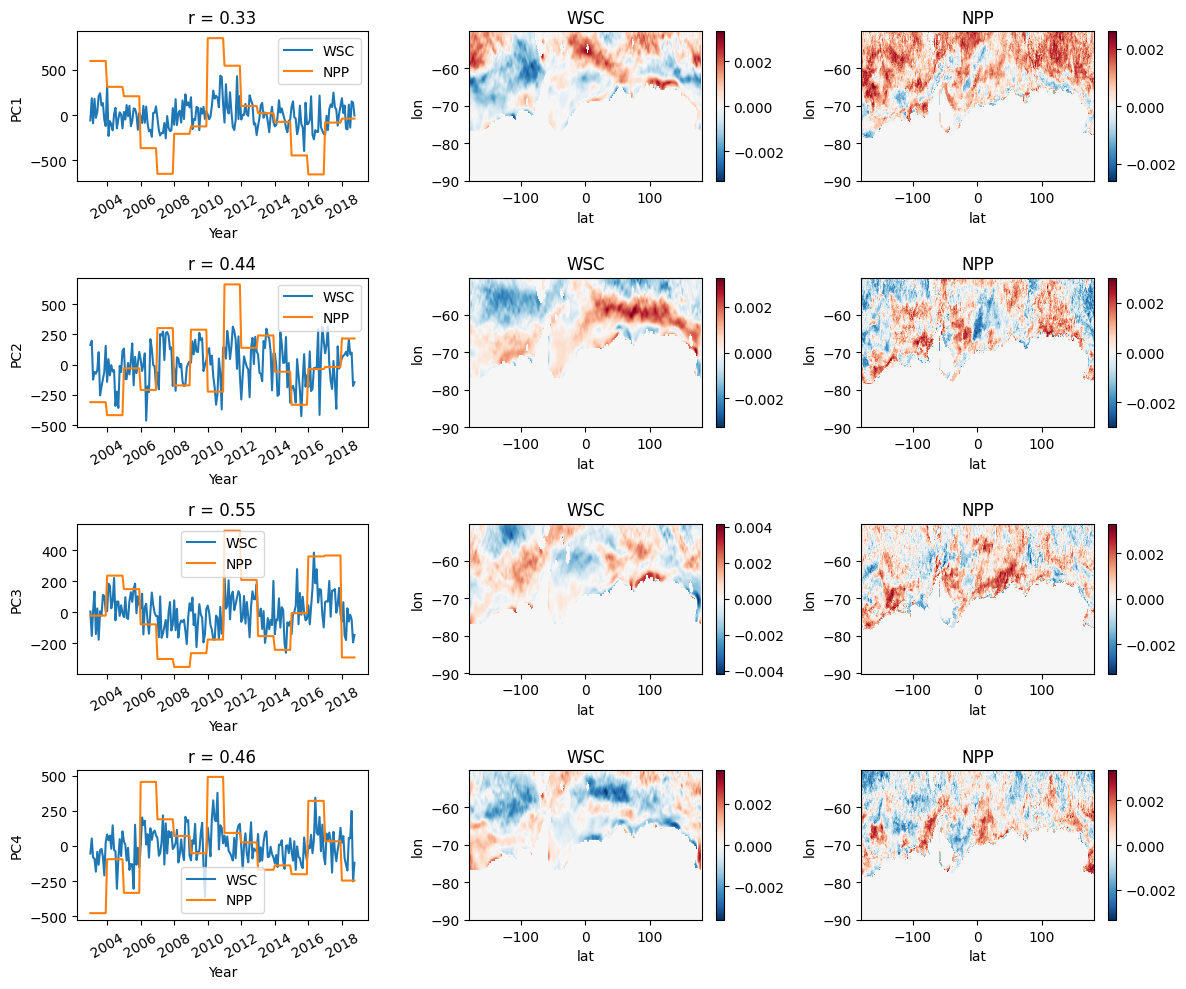

In [95]:
import inspect

model = xe.cross.MCA(n_modes=15, standardize=True)
#print(dir(model))

print(ws_curl_xa.coords)

print(dir(model))
print(ws_curl_xa.dims)
#print(ws_curl_xa.dims)
# model.fit(dot_xa, ws_curl_xa, dim='time')
model.fit(ws_curl_xa, NPP_xa, dim='time')
comps1, comps2 = model.components()  # Singular vectors (spatial patterns)
scores1, scores2 = model.scores()  # Expansion coefficients (temporal patterns)
s1 = scores1.values;
s2 = scores2.values
c1 = comps1.values;
c2 = comps2.values
print(path)
print(gridtype)
# Full path to the 'results' directory
results_dir = os.path.join(path, 'results')

# Check if the directory already exists
if os.path.exists(results_dir):
    print("Directory already exists")
else:
    # Create the directory if it doesn't exist
    os.makedirs(results_dir, exist_ok=True)
    print("Directory created!")
# # write PCs on files
# # fname = path + 'results/PCs_dot_' + gridtype + '.txt'
# fname = path + 'results/PCs_dot_' + gridtype + '_seas.txt'
# with open(fname, 'w') as file:
#     file.write('time\tPC1\tPC2\tPC3\n')
#     for i in range(len(time_dot)):
#         file.write(f'{time_dot[i]}\t{s1[0,i]}\t{s1[1,i]}\t{s1[2,i]}\n')
# file.close()
#
# # fname = path + 'results/PCs_ws_curl_' + gridtype + '.txt'
# fname = path + 'results/PCs_ws_curl_' + gridtype + '_seas.txt'
# with open(fname, 'w') as file:
#     file.write('time\tPC1\tPC2\tPC3\n')
#     for i in range(len(time_dot)):
#         file.write(f'{time_dot[i]}\t{s2[0,i]}\t{s2[1,i]}\t{s2[2,i]}\n')
# file.close()
#how can you change from using cross.MCA to calling the subplots PCA1, PCA2, PCA3 etc ...
r_pears = [];
p_pears = []
r_spear = [];
p_spear = []
for m in range(1, 5):
    x = scores1.sel(mode=m)
    y = scores2.sel(mode=m)
    r, p = scipy.stats.pearsonr(x, y)
    r_pears.append(np.round(r, 2));
    p_pears.append(np.round(p, 2))
    r, p = scipy.stats.spearmanr(x, y)
    r_spear.append(np.round(r, 2));
    p_spear.append(np.round(p, 2))
fig = plt.figure(figsize=(12, 10))

for i in range(0, 4):
    j = 3 * i + 1  # a = 2*(i+1) + i - 1

    plt.subplot(4, 3, j)
    scores1.sel(mode=i + 1).plot(label='WSC')
    scores2.sel(mode=i + 1).plot(label='NPP')
    plt.title('r = ' + str(r_spear[i]))
    plt.xlabel('Year');
    plt.ylabel('PC' + str(int(i + 1)))
    plt.xticks(rotation=30)
    plt.legend()

    plt.subplot(4, 3, j + 1)
    comps1.sel(mode=i + 1).plot()
    plt.title('WSC')

    plt.subplot(4, 3, j + 2)
    comps2.sel(mode=i + 1).plot()
    plt.title('NPP')

fig.tight_layout()

# fig.savefig(path + 'results/MCA_output_' + gridtype + '_seas.png')
# compute squared covariance fraction (equivalent to explained variance in PCA)
sq_cov_frac = model.squared_covariance_fraction()
scf = sq_cov_frac.values
cum_sum = np.cumsum(scf)
print('Cumulative sum of squares:', cum_sum)
print('Squared covariance fraction:', scf)
print(type(cum_sum))
print(len(cum_sum))
mode_percent = []
for i in range(len(cum_sum)):
    if i == 0:
        each_mode_percent = float(cum_sum[i])
        mode_percent.append(each_mode_percent)
    else:
        each_mode_percent = float(cum_sum[i] - cum_sum[i - 1])
        mode_percent.append(each_mode_percent)
print('PCA fraction', mode_percent)


(480, 4320)
(4320,)
(480,)


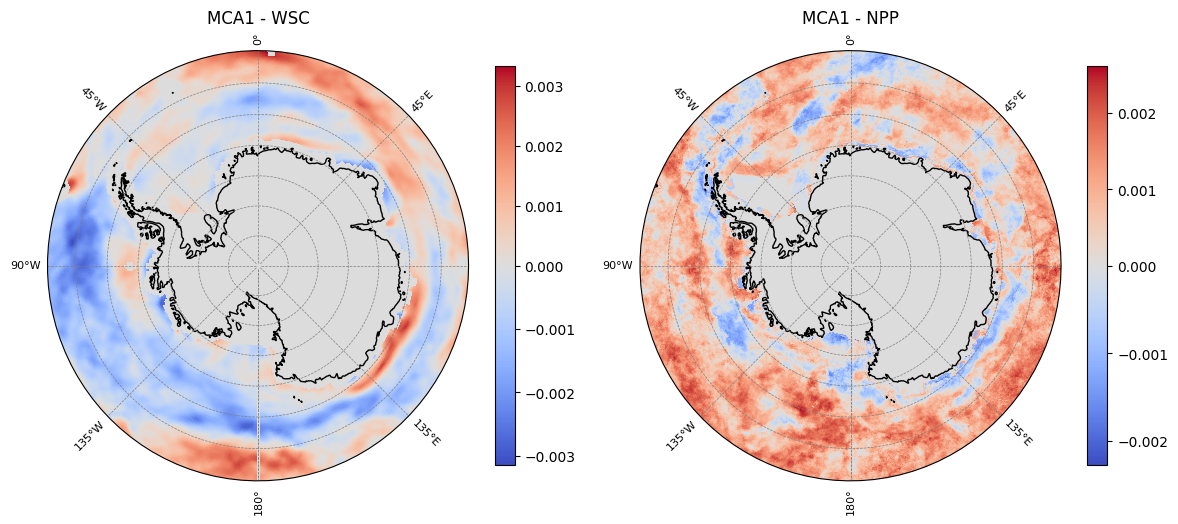

In [101]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib import colors
from polar_plot_utils import plot_curvilinear_data

# Assuming comps1 and comps2 are already defined and contain your data
comp1 = comps1.sel(mode=1)
comp2 = comps2.sel(mode=1)
lon = comp1.lat.values
lat = comp1.lon.values
data1 = comp1.values
data2 = comp2.values


print(data1.shape)
print(lon.shape)
print(lat.shape)
# Create figure and axes for two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6), subplot_kw={'projection': ccrs.SouthPolarStereo()})

# Plot data1 (Left subplot)
pc1 = plot_curvilinear_data(axes[0], data1,lon, lat, "MCA1 - WSC")

# Plot data2 (Right subplot)
pc2 = plot_curvilinear_data(axes[1], data2, lon, lat, "MCA1 - NPP")

# Add colorbars for both subplots
# fig.colorbar(pc1, ax=axes[0], orientation='vertical', label='Amplitude', shrink=0.7, pad=0.05)
# fig.colorbar(pc2, ax=axes[1], orientation='vertical', label='Amplitude', shrink=0.7, pad=0.05)

plt.tight_layout()
plt.show()


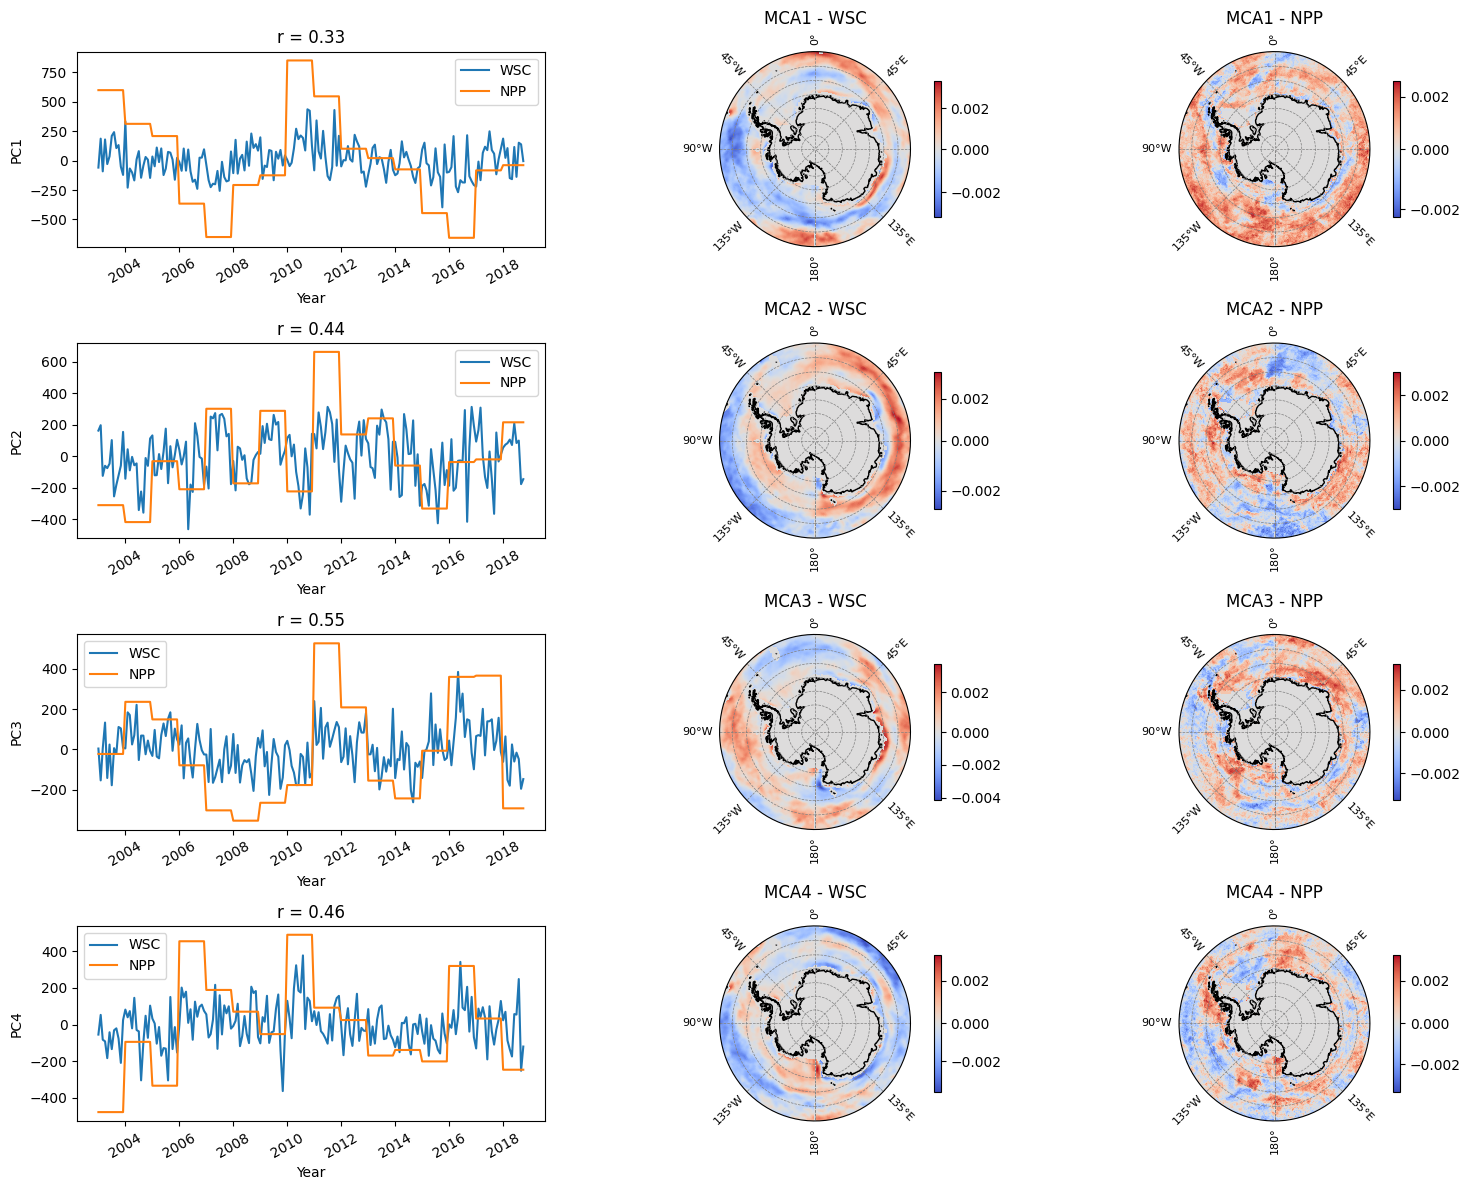

In [103]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib import colors
import scipy.stats
from matplotlib.gridspec import GridSpec

# Assuming comps1 and comps2 are already defined (MCA components)
comps1, comps2 = model.components()  # Singular vectors (spatial patterns)
scores1, scores2 = model.scores()  # Expansion coefficients (temporal patterns)
s1 = scores1.values
s2 = scores2.values
c1 = comps1.values
c2 = comps2.values


# Initialize lists for correlation coefficients
r_pears = []
p_pears = []
r_spear = []
p_spear = []

# Calculate correlation coefficients
for m in range(1, 5):
    x = scores1.sel(mode=m)
    y = scores2.sel(mode=m)
    r, p = scipy.stats.pearsonr(x, y)
    r_pears.append(np.round(r, 2))
    p_pears.append(np.round(p, 2))
    r, p = scipy.stats.spearmanr(x, y)
    r_spear.append(np.round(r, 2))
    p_spear.append(np.round(p, 2))

# Create the figure and GridSpec
fig = plt.figure(figsize=(15, 12))  # Adjust figure size to accommodate bigger columns
gs = GridSpec(4, 3, figure=fig, width_ratios=[2, 2, 2])  # Column widths: 1 for column 1, 2 for columns 2 and 3

# Loop over modes 1 to 4 and plot results
for i in range(0, 4):
    j = 3 * i  # Column position for scores plots

    # Plot scores (time series) in 1st column
    ax1 = fig.add_subplot(gs[i, 0])  # Use gs to position the subplot in the 1st column
    scores1.sel(mode=i + 1).plot(ax=ax1, label='WSC')
    scores2.sel(mode=i + 1).plot(ax=ax1, label='NPP')
    ax1.set_title('r = ' + str(r_spear[i]))
    ax1.set_xlabel('Year')
    ax1.set_ylabel('PC' + str(int(i + 1)))
    ax1.tick_params(axis='x', rotation=30)
    ax1.legend()

    # Create circular plot for SSH in 2nd column
    ax2 = fig.add_subplot(gs[i, 1], projection=ccrs.SouthPolarStereo())  # 2nd column (bigger)
    comp1 = comps1.sel(mode=i + 1)
    lon = comp1.lat.values
    lat = comp1.lon.values
    data1 = comp1.values
    plot_curvilinear_data(ax2, data1,lon, lat, "MCA" + str(i + 1) + " - WSC")

    # Create circular plot for WSC in 3rd column
    ax3 = fig.add_subplot(gs[i, 2], projection=ccrs.SouthPolarStereo())  # 3rd column (bigger)
    comp2 = comps2.sel(mode=i + 1)
    data2 = comp2.values
    plot_curvilinear_data(ax3, data2, lon,lat, "MCA" + str(i + 1) + " - NPP")

# Adjust layout to prevent overlap
fig.tight_layout()
plt.show()
